# 8.4 激活函数、损失函数与决策函数

> **课时**：1课时 | **难度**：⭐⭐⭐ | **竞赛重要度**：⭐⭐⭐⭐⭐

## 📚 学习目标

1. 掌握常用激活函数的数学定义、图像和导数
2. 理解各激活函数的优缺点与适用场景
3. 理解梯度消失/爆炸与激活函数的关系
4. 掌握常用损失函数的数学形式与适用场景
5. 理解决策函数的概念
6. 通过可视化深入理解这些函数的特性

---

## 1. 常用激活函数

激活函数为神经网络引入**非线性**，使其能够学习复杂的模式。

### 1.1 Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**导数**：

$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

| 优点 | 缺点 |
|------|------|
| 输出在 $(0, 1)$ 之间，可解释为概率 | 梯度消失严重（最大导数仅 0.25） |
| 平滑可导 | 输出非零中心（会导致梯度更新效率低） |
| 适合二分类输出层 | 计算涉及指数运算（稍慢） |

**适用场景**：二分类网络的**输出层**

### 1.2 Tanh（双曲正切）

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

**导数**：

$$\tanh'(z) = 1 - \tanh^2(z)$$

| 优点 | 缺点 |
|------|------|
| 输出零中心（$(-1, 1)$） | 仍有梯度消失问题（但比 Sigmoid 好） |
| 最大导数为 1（比 Sigmoid 的 0.25 大） | 两端饱和 |

**适用场景**：RNN 的隐藏层、需要零中心输出的场景

### 1.3 ReLU（Rectified Linear Unit）

$$\text{ReLU}(z) = \max(0, z)$$

**导数**：

$$\text{ReLU}'(z) = \begin{cases} 1, & z > 0 \\ 0, & z \leq 0 \end{cases}$$

| 优点 | 缺点 |
|------|------|
| 计算极快（仅需 max 操作） | **Dead ReLU 问题**：神经元可能永久"死亡" |
| 正区间梯度恒为 1（缓解梯度消失） | 输出非零中心 |
| 稀疏激活（生物学合理性） | $z > 0$ 时梯度恒为 1，可能梯度爆炸 |

**适用场景**：**隐藏层的默认选择**，大多数 CNN 和全连接网络

### 1.4 Leaky ReLU

$$\text{LeakyReLU}(z) = \begin{cases} z, & z > 0 \\ \alpha z, & z \leq 0 \end{cases}$$

其中 $\alpha$ 通常取 0.01。

**导数**：

$$\text{LeakyReLU}'(z) = \begin{cases} 1, & z > 0 \\ \alpha, & z \leq 0 \end{cases}$$

| 优点 | 缺点 |
|------|------|
| 解决 Dead ReLU 问题 | $\alpha$ 需要手动设定 |
| 计算简单 | $z < 0$ 时仍有微小梯度泄漏 |

### 1.5 GELU（Gaussian Error Linear Unit）

$$\text{GELU}(z) = z \cdot \Phi(z)$$

其中 $\Phi(z)$ 是标准正态分布的累积分布函数。

**近似公式**：

$$\text{GELU}(z) \approx 0.5z\left(1 + \tanh\left[\sqrt{2/\pi}\left(z + 0.044715z^3\right)\right]\right)$$

| 优点 | 缺点 |
|------|------|
| 平滑的非线性变换 | 计算量比 ReLU 大 |
| 在 Transformer 中表现优异 | |

**适用场景**：**Transformer 架构（GPT、BERT）的标准激活函数**

### 1.6 Softmax

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**特点**：
- 将 $K$ 个实数映射为概率分布（所有输出之和为 1）
- 通常用于**多分类的输出层**

**导数（Jacobian）**：

$$\frac{\partial \text{Softmax}_i}{\partial z_j} = \text{Softmax}_i(\delta_{ij} - \text{Softmax}_j)$$

---

## 2. 激活函数对比总结

| 激活函数 | 输出范围 | 零中心？ | 梯度消失？ | 主要用途 |
|---------|---------|:--------:|:---------:|---------|
| Sigmoid | $(0, 1)$ | ✗ | 严重 | 二分类输出 |
| Tanh | $(-1, 1)$ | ✓ | 中等 | RNN 隐藏层 |
| ReLU | $[0, +\infty)$ | ✗ | 轻微 | 隐藏层默认 |
| Leaky ReLU | $(-\infty, +\infty)$ | ✗ | 轻微 | ReLU 的改进 |
| GELU | $(-\infty, +\infty)$ | ≈✓ | 轻微 | Transformer |
| Softmax | $(0, 1), \sum=1$ | ✗ | - | 多分类输出 |

---

## 3. 梯度消失/爆炸与激活函数

### 3.1 梯度消失的原因

在反向传播中，梯度逐层相乘：

$$\frac{\partial L}{\partial W^{(1)}} \propto \prod_{l=1}^{L} f'(z^{(l)})$$

| 激活函数 | 最大导数 | $L=10$ 层后 | $L=50$ 层后 |
|---------|:-------:|:----------:|:----------:|
| Sigmoid | 0.25 | $0.25^{10} \approx 10^{-6}$ | $0.25^{50} \approx 10^{-30}$ |
| Tanh | 1.0 | $1^L = 1$ | 理论上不消失（但实际中大部分区域导数<1） |
| ReLU | 1.0 | 不消失 | 不消失 |

### 3.2 解决方案

| 方案 | 原理 |
|------|------|
| 使用 ReLU/GELU | 正区间导数为常数 |
| 残差连接 | 梯度可以直接"跳过"某些层 |
| 批量归一化 | 稳定每层的输入分布 |
| 合理初始化（Xavier/He） | 保持梯度方差在合理范围 |

---

## 4. 常用损失函数

### 4.1 均方误差（MSE）——回归

$$L_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

**梯度**：

$$\frac{\partial L}{\partial \hat{y}_i} = \frac{2}{N}(\hat{y}_i - y_i)$$

**适用场景**：回归问题

### 4.2 二元交叉熵（BCE）——二分类

$$L_{\text{BCE}} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

**梯度**：

$$\frac{\partial L}{\partial \hat{y}_i} = \frac{1}{N}\left(\frac{\hat{y}_i - y_i}{\hat{y}_i(1-\hat{y}_i)}\right)$$

**适用场景**：二分类（配合 Sigmoid 输出层）

### 4.3 交叉熵损失（CE）——多分类

$$L_{\text{CE}} = -\sum_{i=1}^{N}\sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$

**适用场景**：多分类（配合 Softmax 输出层）

> **重要**：交叉熵损失 + Softmax 输出 = 逻辑回归的多分类推广。在竞赛中，**分类问题首选交叉熵**。

---

## 5. 决策函数（Decision Function）

### 5.1 概念

决策函数是模型用来做分类决策的函数，它将模型的原始输出转化为最终的类别标签。

### 5.2 常见形式

**二分类**：

$$\hat{y} = \begin{cases} 1, & f(\mathbf{x}) \geq 0 \\ 0, & f(\mathbf{x}) < 0 \end{cases}$$

**多分类**：

$$\hat{y} = \arg\max_c f_c(\mathbf{x})$$

### 5.3 与激活函数的关系

| 场景 | 输出层激活 | 决策规则 |
|------|-----------|---------|
| 二分类 | Sigmoid | $\hat{y} = 1$ if $\sigma(z) \geq 0.5$ |
| 多分类 | Softmax | $\hat{y} = \arg\max_c \text{Softmax}(z)_c$ |
| 回归 | 无（线性） | $\hat{y} = z$ |

### 5.4 决策边界

决策函数的等值面就是**决策边界**（Decision Boundary）：
- 线性模型：决策边界是超平面
- 非线性模型（神经网络）：决策边界可以是任意形状

---

## 6. 竞赛考点总结

| 考点 | 重要程度 |
|------|---------|
| Sigmoid/ReLU 的公式与导数 | ⭐⭐⭐⭐⭐ |
| 各激活函数的优缺点对比 | ⭐⭐⭐⭐⭐ |
| 梯度消失与激活函数的关系 | ⭐⭐⭐⭐⭐ |
| Softmax 的公式与性质 | ⭐⭐⭐⭐⭐ |
| MSE vs 交叉熵的选择 | ⭐⭐⭐⭐ |
| GELU 在 Transformer 中的应用 | ⭐⭐⭐⭐ |
| 决策函数的概念 | ⭐⭐⭐⭐ |


## 7. 代码实战

### 7.1 可视化各激活函数及其导数

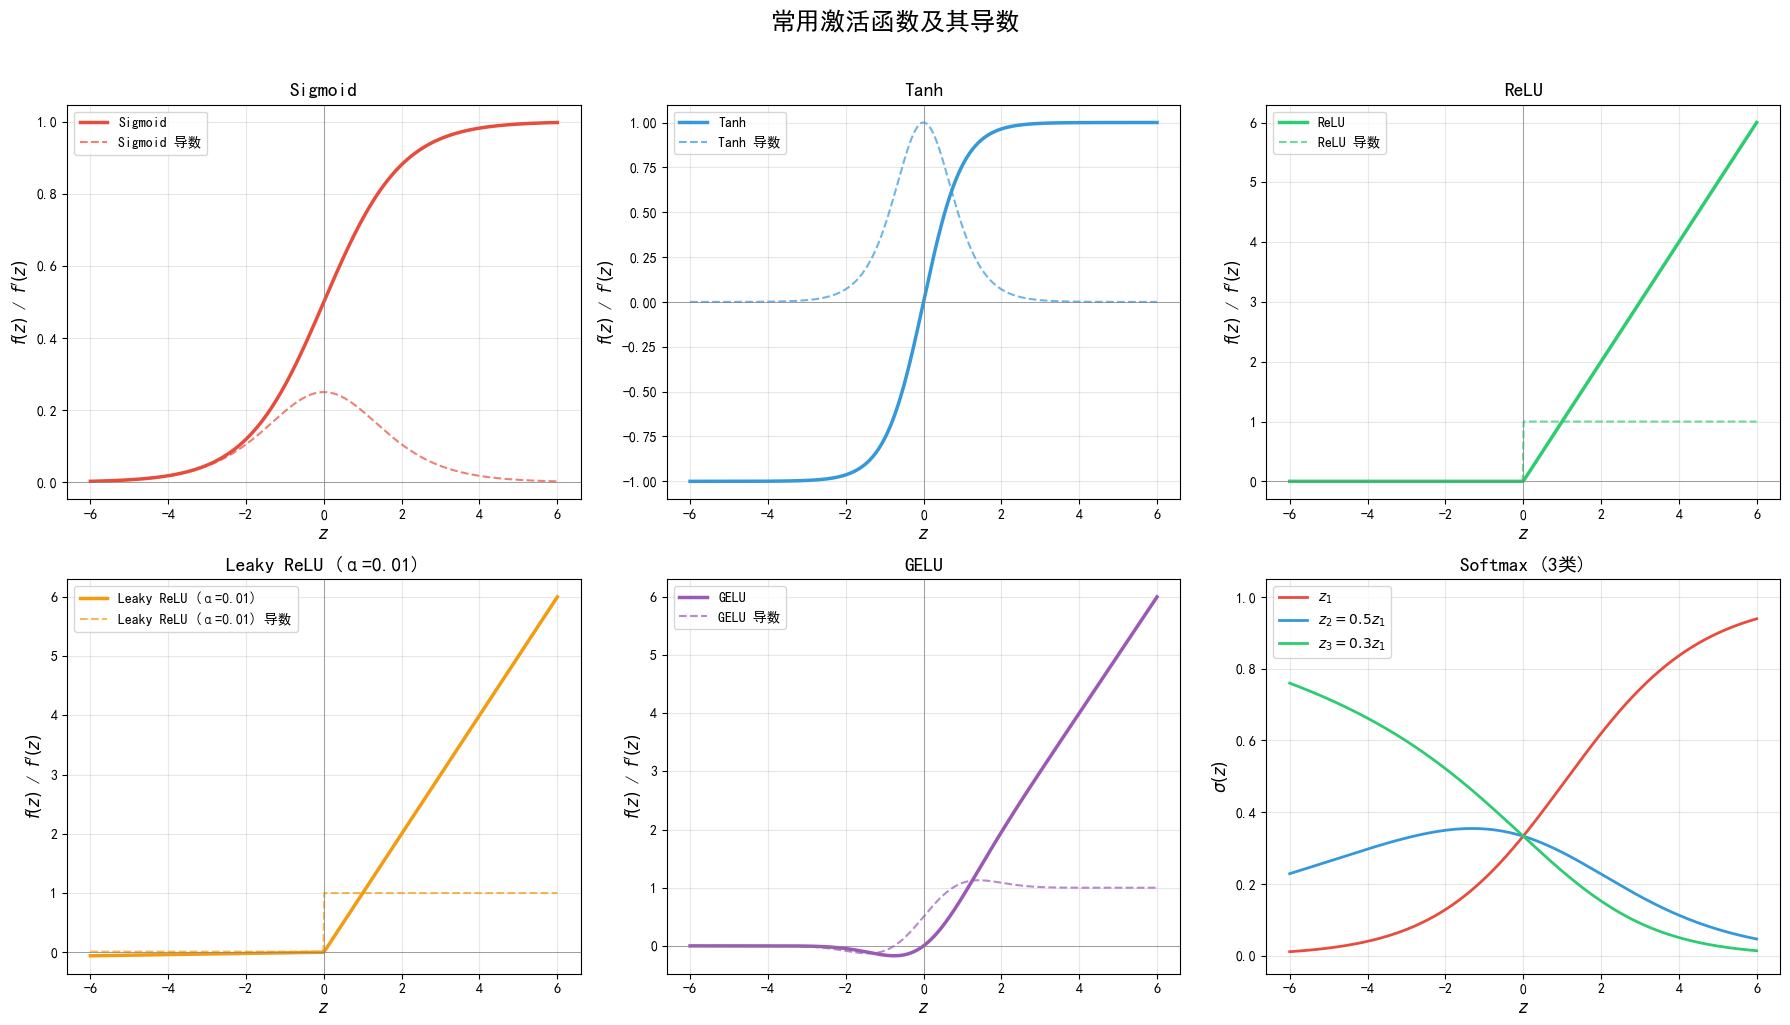

激活函数关键特性总结
  Sigmoid: 输出(0,1)，导数最大0.25，易梯度消失
  Tanh:    输出(-1,1)，零中心，导数最大1.0
  ReLU:    输出[0,∞)，正区间导数恒为1，有Dead ReLU问题
  LReLU:   解决Dead ReLU，z<0时有微小梯度
  GELU:    平滑非线性，Transformer标配


In [11]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'STSong', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
# ============================================
# 定义激活函数及其导数
# ============================================

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_fn(z):
    return np.tanh(z)

def tanh_deriv(z):
    return 1 - np.tanh(z)**2

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return np.where(z > 0, 1.0, 0.0)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_deriv(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

def gelu(z):
    """GELU 近似"""
    return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

def gelu_deriv(z):
    eps = 1e-7
    return (gelu(z + eps) - gelu(z - eps)) / (2 * eps)

# ============================================
# 绘制激活函数
# ============================================
z = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

activations = [
    ('Sigmoid', sigmoid, sigmoid_deriv, '#e74c3c'),
    ('Tanh', tanh_fn, tanh_deriv, '#3498db'),
    ('ReLU', relu, relu_deriv, '#2ecc71'),
    ('Leaky ReLU (α=0.01)', leaky_relu, leaky_relu_deriv, '#f39c12'),
    ('GELU', gelu, gelu_deriv, '#9b59b6'),
    ('Softmax (3类)', None, None, '#1abc9c'),
]

for idx, (name, fn, deriv_fn, color) in enumerate(activations):
    ax = axes[idx]
    
    if name == 'Softmax (3类)':
        # Softmax 特殊处理
        z3 = np.array([z, z*0.5, z*0.3]).T
        exp_z = np.exp(z3 - np.max(z3, axis=1, keepdims=True))
        softmax_out = exp_z / np.sum(exp_z, axis=1, keepdims=True)
        ax.plot(z, softmax_out[:, 0], '-', color='#e74c3c', linewidth=2, label='$z_1$')
        ax.plot(z, softmax_out[:, 1], '-', color='#3498db', linewidth=2, label='$z_2 = 0.5z_1$')
        ax.plot(z, softmax_out[:, 2], '-', color='#2ecc71', linewidth=2, label='$z_3 = 0.3z_1$')
        ax.set_title(f'{name}', fontsize=14, fontweight='bold')
        ax.set_xlabel('$z$', fontsize=12)
        ax.set_ylabel('$\sigma(z)$', fontsize=12)
        ax.legend(fontsize=10)
        ax.set_ylim(-0.05, 1.05)
    else:
        # 绘制激活函数
        ax.plot(z, fn(z), '-', color=color, linewidth=2.5, label=f'{name}')
        ax.plot(z, deriv_fn(z), '--', color=color, linewidth=1.5, alpha=0.7, label=f'{name} 导数')
        ax.set_title(f'{name}', fontsize=14, fontweight='bold')
        ax.set_xlabel('$z$', fontsize=12)
        ax.set_ylabel(r"$f(z)$ / $f'(z)$", fontsize=12)
   
        ax.legend(fontsize=10)
        ax.axhline(y=0, color='gray', linewidth=0.5)
        ax.axvline(x=0, color='gray', linewidth=0.5)
    
    ax.grid(True, alpha=0.3)

plt.suptitle('常用激活函数及其导数', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 60)
print("激活函数关键特性总结")
print("=" * 60)
print("  Sigmoid: 输出(0,1)，导数最大0.25，易梯度消失")
print("  Tanh:    输出(-1,1)，零中心，导数最大1.0")
print("  ReLU:    输出[0,∞)，正区间导数恒为1，有Dead ReLU问题")
print("  LReLU:   解决Dead ReLU，z<0时有微小梯度")
print("  GELU:    平滑非线性，Transformer标配")

### 7.2 比较损失函数的曲面

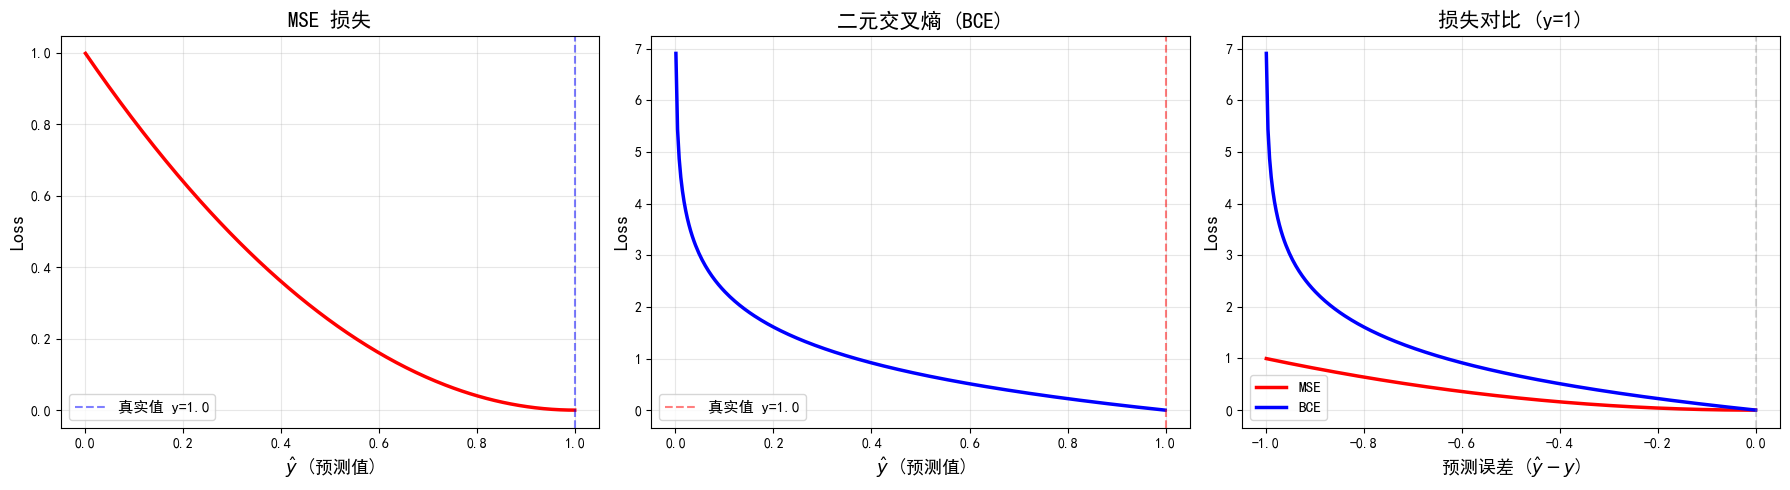

观察要点:
  - MSE 对预测误差的惩罚是二次的，预测越偏离真实值惩罚越大
  - BCE 在预测值接近0时损失趋向无穷大（防止预测为0）
  - BCE 在预测值接近真实值时，梯度比MSE更大（收敛更快）


In [12]:
# ============================================
# 损失函数曲面可视化
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 真实值
y_true = 1.0
y_pred = np.linspace(0.001, 0.999, 300)

# 1. MSE 损失
mse_loss = (y_true - y_pred)**2
ax1 = axes[0]
ax1.plot(y_pred, mse_loss, 'r-', linewidth=2.5)
ax1.set_title('MSE 损失', fontsize=15, fontweight='bold')
ax1.set_xlabel('$\hat{y}$ (预测值)', fontsize=13)
ax1.set_ylabel('Loss', fontsize=13)
ax1.axvline(x=y_true, color='blue', linestyle='--', alpha=0.5, label=f'真实值 y={y_true}')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. 二元交叉熵
bce_loss = -(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))
ax2 = axes[1]
ax2.plot(y_pred, bce_loss, 'b-', linewidth=2.5)
ax2.set_title('二元交叉熵 (BCE)', fontsize=15, fontweight='bold')
ax2.set_xlabel('$\hat{y}$ (预测值)', fontsize=13)
ax2.set_ylabel('Loss', fontsize=13)
ax2.axvline(x=y_true, color='red', linestyle='--', alpha=0.5, label=f'真实值 y={y_true}')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. 比较两种损失（对预测误差的敏感度）
ax3 = axes[2]
error = y_pred - y_true
ax3.plot(error, mse_loss, 'r-', linewidth=2.5, label='MSE')
ax3.plot(error, bce_loss, 'b-', linewidth=2.5, label='BCE')
ax3.set_title('损失对比 (y=1)', fontsize=15, fontweight='bold')
ax3.set_xlabel('预测误差 ($\hat{y} - y$)', fontsize=13)
ax3.set_ylabel('Loss', fontsize=13)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("观察要点:")
print("  - MSE 对预测误差的惩罚是二次的，预测越偏离真实值惩罚越大")
print("  - BCE 在预测值接近0时损失趋向无穷大（防止预测为0）")
print("  - BCE 在预测值接近真实值时，梯度比MSE更大（收敛更快）")

### 7.3 梯度消失可视化：不同激活函数深层传播后的梯度幅度

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

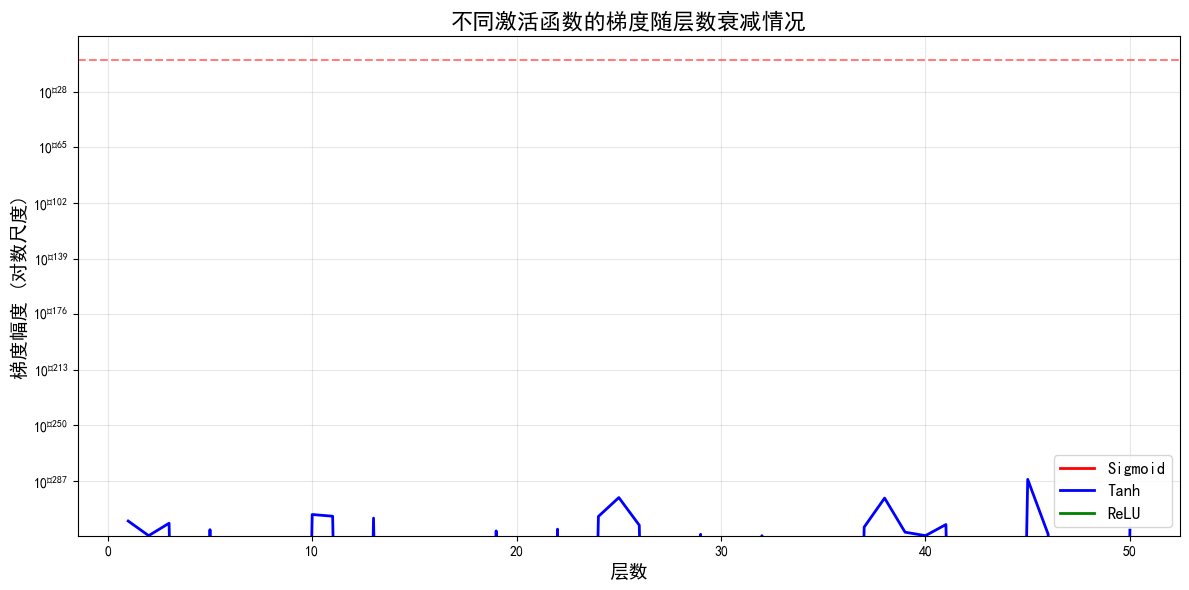

关键发现:
  - Sigmoid 的梯度以指数速度衰减，50层后几乎为零 → 梯度消失严重
  - Tanh 的梯度衰减较慢，但深层网络仍可能消失
  - ReLU 的梯度在正区间保持为1，几乎不消失（但有Dead ReLU风险）

这就是为什么深度网络中 ReLU 系列激活函数取代了 Sigmoid/Tanh！


In [13]:
# ============================================
# 梯度消失/爆炸模拟
# ============================================

np.random.seed(42)
num_layers = 50
np.random.seed(42)

# 模拟不同激活函数下梯度经过多层后的变化
# 假设每层的加权输入 z 在 [-2, 2] 范围内随机分布

# 初始梯度（从损失函数传来的）
grad_input = np.ones(1000)  # 1000 个神经元

# 模拟经过 L 层后的梯度变化
sigmoid_grads = []
tanh_grads = []
relu_grads = []

for L in range(1, num_layers + 1):
    z = np.random.randn(1000) * 1.0  # 加权输入
    
    # Sigmoid: 梯度乘以 σ'(z) = σ(z)(1-σ(z))，最大0.25
    sig_deriv = sigmoid(z) * (1 - sigmoid(z))
    sigmoid_grads.append(np.abs(np.prod(sig_deriv)))
    
    # Tanh: 梯度乘以 tanh'(z) = 1-tanh²(z)，最大1.0
    tanh_deriv_val = 1 - np.tanh(z)**2
    tanh_grads.append(np.abs(np.prod(tanh_deriv_val)))
    
    # ReLU: 导数为0或1，约50%为0，50%为1
    relu_deriv_val = (z > 0).astype(float)
    relu_grads.append(np.abs(np.prod(relu_deriv_val)))

layers = np.arange(1, num_layers + 1)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(layers, sigmoid_grads, 'r-', linewidth=2, label='Sigmoid')
ax.plot(layers, tanh_grads, 'b-', linewidth=2, label='Tanh')
ax.plot(layers, relu_grads, 'g-', linewidth=2, label='ReLU')
ax.set_yscale('log')
ax.set_xlabel('层数', fontsize=14)
ax.set_ylabel('梯度幅度 (对数尺度)', fontsize=14)
ax.set_title('不同激活函数的梯度随层数衰减情况', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which='both')
ax.axhline(y=1e-7, color='red', linestyle='--', alpha=0.5, label='阈值 ($10^{-7}$)')

plt.tight_layout()
plt.show()

print("关键发现:")
print("  - Sigmoid 的梯度以指数速度衰减，50层后几乎为零 → 梯度消失严重")
print("  - Tanh 的梯度衰减较慢，但深层网络仍可能消失")
print("  - ReLU 的梯度在正区间保持为1，几乎不消失（但有Dead ReLU风险）")
print("")
print("这就是为什么深度网络中 ReLU 系列激活函数取代了 Sigmoid/Tanh！")

### 7.4 Softmax 概率分布可视化

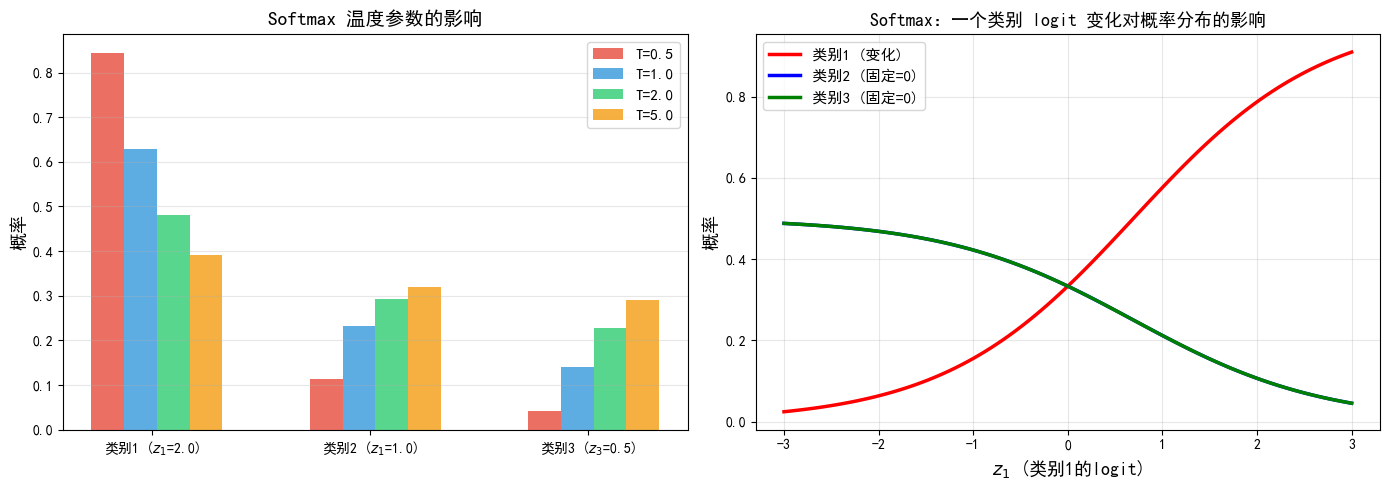

Softmax 的关键性质:
  1. 所有输出概率之和为 1
  2. 温度 T 越小 → 概率分布越尖锐（更确定）
  3. 温度 T 越大 → 概率分布越平滑（更均匀）
  4. 增大某一类的 logit 会减小其他所有类的概率


In [14]:
# ============================================
# Softmax 概率分布可视化
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：温度参数对 Softmax 的影响
z_scores = np.array([2.0, 1.0, 0.5])
temperatures = [0.5, 1.0, 2.0, 5.0]
colors_temp = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

ax1 = axes[0]
for T, color in zip(temperatures, colors_temp):
    probs = np.exp(z_scores / T) / np.sum(np.exp(z_scores / T))
    ax1.bar(np.arange(3) + temperatures.index(T)*0.15, probs, width=0.15, 
            color=color, alpha=0.8, label=f'T={T}')

ax1.set_xticks(np.arange(3) + 0.2)
ax1.set_xticklabels(['类别1 ($z_1$=2.0)', '类别2 ($z_1$=1.0)', '类别3 ($z_3$=0.5)'], fontsize=10)
ax1.set_ylabel('概率', fontsize=13)
ax1.set_title('Softmax 温度参数的影响', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 右图：Softmax 的特性——输入变化对输出的影响
ax2 = axes[1]
z1_range = np.linspace(-3, 3, 100)
z2_fixed, z3_fixed = 0.0, 0.0
probs = np.zeros((len(z1_range), 3))
for i, z1 in enumerate(z1_range):
    z = np.array([z1, z2_fixed, z3_fixed])
    exp_z = np.exp(z - np.max(z))
    probs[i] = exp_z / np.sum(exp_z)

ax2.plot(z1_range, probs[:, 0], 'r-', linewidth=2.5, label='类别1 (变化)')
ax2.plot(z1_range, probs[:, 1], 'b-', linewidth=2.5, label='类别2 (固定=0)')
ax2.plot(z1_range, probs[:, 2], 'g-', linewidth=2.5, label='类别3 (固定=0)')
ax2.set_xlabel('$z_1$ (类别1的logit)', fontsize=13)
ax2.set_ylabel('概率', fontsize=13)
ax2.set_title('Softmax：一个类别 logit 变化对概率分布的影响', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Softmax 的关键性质:")
print("  1. 所有输出概率之和为 1")
print("  2. 温度 T 越小 → 概率分布越尖锐（更确定）")
print("  3. 温度 T 越大 → 概率分布越平滑（更均匀）")
print("  4. 增大某一类的 logit 会减小其他所有类的概率")

---

## 📝 练习题

### 题目 1：激活函数计算

**Q1.** 计算 Sigmoid(0)、Sigmoid(10)、Sigmoid(-10) 的值，并解释结果。

<details>
<summary>点击查看答案</summary>

- $\sigma(0) = \frac{1}{1+1} = 0.5$
- $\sigma(10) = \frac{1}{1+e^{-10}} \approx 0.99995$（接近 1，饱和区）
- $\sigma(-10) = \frac{1}{1+e^{10}} \approx 0.00005$（接近 0，饱和区）

Sigmoid 在输入远离 0 时进入**饱和区**，导数趋近于 0，导致梯度消失。

</details>

### 题目 2：对比分析

**Q2.** 为什么 ReLU 比 Sigmoid 更适合作为深度网络的隐藏层激活函数？请至少给出两个理由。

<details>
<summary>点击查看答案</summary>

1. **缓解梯度消失**：ReLU 在正区间的导数恒为 1，而 Sigmoid 的最大导数仅 0.25。深层网络中，Sigmoid 的梯度会指数级衰减。
2. **计算效率**：ReLU 只需 max 操作，而 Sigmoid 需要指数运算。
3. **稀疏激活**：ReLU 使约一半的神经元输出为 0，产生稀疏表示，有利于特征选择。

</details>

### 题目 3：损失函数选择

**Q3.** 对于以下场景，应该选择哪种损失函数？
- (a) 预测房价
- (b) 判断邮件是否为垃圾邮件
- (c) 识别手写数字（0-9）

<details>
<summary>点击查看答案</summary>

- (a) **MSE**（回归任务）
- (b) **二元交叉熵 BCE**（二分类任务，配合 Sigmoid 输出层）
- (c) **交叉熵 CE**（多分类任务，配合 Softmax 输出层）

</details>

### 题目 4：Softmax 性质

**Q4.** 证明 Softmax 函数的输出之和为 1。

<details>
<summary>点击查看答案</summary>

$$\sum_{i=1}^{K} \text{Softmax}(z_i) = \sum_{i=1}^{K}\frac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}} = \frac{\sum_{i=1}^{K}e^{z_i}}{\sum_{j=1}^{K}e^{z_j}} = \frac{\sum_{i=1}^{K}e^{z_i}}{\sum_{i=1}^{K}e^{z_i}} = 1$$

分子和分母相同，因此结果为 1。这保证了输出可以解释为概率分布。

</details>

### 题目 5：竞赛真题风格

**Q5.** 以下关于激活函数的说法，正确的是（ ）

A. ReLU 函数在负半轴的导数恒为 1
B. GELU 是 GPT 和 BERT 中使用的激活函数
C. Softmax 函数的输出范围是 $(-\infty, +\infty)$
D. Tanh 函数的输出范围是 $(0, 1)$

<details>
<summary>点击查看答案</summary>

**答案：B**

- A 错误：ReLU 在负半轴导数为 0（不是 1）
- B 正确：GELU 是 Transformer 的标准激活函数
- C 错误：Softmax 输出范围是 $(0, 1)$，且和为 1
- D 错误：Tanh 输出范围是 $(-1, 1)$（Sigmoid 才是 $(0, 1)$）

</details>
